# **Exercise 1**

# Question 1: 

# ***Linear Programming Formulation :***

### ***Decision Variables :***
Let
$$
x_{ij} = \text{quantity shipped from Plant  i  to Distribution Center j}
$$
where
$$
i = 1,2,3 \quad ; \quad j = 1,\dots,12
$$
$$
x_{ij} \ge 0
$$

### ***Parameters :***
- Selling price = ₹20 per unit  
- Production cost at plant $i$: $c_i$  
- Transportation cost from plant $i$ to DC $j$: $t_{ij}$  
- Capacity of plant $i$: $S_i$  
- Demand at DC $j$: $D_j$

### ***Objective Function (Maximize Profit) :***
Profit per unit shipped from plant $i$ to DC $j$:
$$
20 - (c_i + t_{ij})
$$

Total profit:
$$
\max Z =
\sum_{i=1}^{3} \sum_{j=1}^{12}
\left[ 20 - (c_i + t_{ij}) \right] x_{ij}
$$

### ***Constraints :***

#### *1. Plant Capacity Constraints :*
- Total Supply = 120 + 90 + 100 = 310 units  
- Total Demand = 20 + 30 + 40 + 35 + 15 + 19 + 25 + 20 + 18 + 12 + 30 + 40 = 304 units  

Since Total Supply (310) > Total Demand (304),  
the given problem is an **Unbalanced Transportation Problem** with an excess supply of 6 units.

Therefore, the plant capacity constraints will be of the form:

$$
\sum_{j=1}^{12} x_{ij} \le S_i \quad for  i = 1,2,3.
$$

Explicitly,

$$
\sum_{j=1}^{12} x_{1j} \le 120,\quad
\sum_{j=1}^{12} x_{2j} \le 90,\quad
\sum_{j=1}^{12} x_{3j} \le 100
$$

#### *2. Demand Satisfaction Constraints :*
For each distribution center $j$:
$$
\sum_{i=1}^{3} x_{ij} = D_j
\quad \text{for } j = 1,\dots,12
$$

Explicitly,

$$
x_{11} + x_{21} + x_{31} = 20
$$
$$
x_{12} + x_{22} + x_{32} = 30
$$
$$
\vdots
$$
$$
x_{1,12} + x_{2,12} + x_{3,12} = 40
$$

#### *3. Non-negativity Constraints :*
$$
x_{ij} \ge 0
$$

# ***Final LP Model :***

$$
\max \sum_{i=1}^{3} \sum_{j=1}^{12}
\left[ 20 - (c_i + t_{ij}) \right] x_{ij}
$$

subject to

$$
\sum_{j=1}^{12} x_{ij} \le S_i
\quad \text{for } i=1,2,3
$$

$$
\sum_{i=1}^{3} x_{ij} = D_j
\quad \text{for } j=1,\dots,12
$$

$$
x_{ij} \ge 0
$$

---

# Question 2

In [1]:
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plants = [1, 2, 3]
dcs = list(range(1, 13))

capacity = {1: 120, 2: 90, 3: 100}
demand = {
    1:20, 2:30, 3:40, 4:35, 5:15, 6:19,
    7:25, 8:20, 9:18, 10:12, 11:30, 12:40
}

prod_cost = {1: 8, 2: 7, 3: 9}
transport_cost = {
    (1,1):2, (1,2):3, (1,3):2, (1,4):3, (1,5):5, (1,6):4.4,
    (1,7):3.2, (1,8):3, (1,9):1.5, (1,10):3, (1,11):6, (1,12):1,
    (2,1):1.9, (2,2):3, (2,3):2.4, (2,4):2.4, (2,5):2, (2,6):4.1,
    (2,7):2.8, (2,8):3, (2,9):1.7, (2,10):2, (2,11):1, (2,12):4.5,
    (3,1):3.1, (3,2):1.8, (3,3):2.8, (3,4):3.4, (3,5):2, (3,6):2.9,
    (3,7):2.2, (3,8):3.2, (3,9):2, (3,10):2.8, (3,11):4.5, (3,12):6
}

selling_price = 20

In [3]:
model = pyo.ConcreteModel()
model.I = pyo.Set(initialize=plants)
model.J = pyo.Set(initialize=dcs)
model.x = pyo.Var(model.I, model.J, domain=pyo.NonNegativeReals)

In [4]:
def profit_rule(model):
    return sum((selling_price - prod_cost[i] - transport_cost[i,j]) * model.x[i,j] for i in model.I for j in model.J)

model.obj = pyo.Objective(rule=profit_rule, sense=pyo.maximize)

In [5]:
def capacity_rule(model, i):
    return sum(model.x[i,j] for j in model.J) <= capacity[i]

def demand_rule(model, j):
    return sum(model.x[i,j] for i in model.I) == demand[j]

model.capacity_con = pyo.Constraint(model.I, rule=capacity_rule)
model.demand_con = pyo.Constraint(model.J, rule=demand_rule)

In [6]:
solver = pyo.SolverFactory('glpk')
solver.solve(model);

In [7]:
print(f"Optimal Profit = {pyo.value(model.obj):.2f}")

allocation = pd.DataFrame([[pyo.value(model.x[i,j]) for j in dcs] for i in plants],
    index=[f"Plant {i}" for i in plants],
    columns=[f"DC{j}" for j in dcs]
)
allocation["Total Sent"] = allocation.sum(axis=1)
allocation.loc["Total Received"] = allocation.sum(axis=0)

print("\nOptimal Shipment Allocation Table :")
allocation

Optimal Profit = 3065.20

Optimal Shipment Allocation Table :


,DC1,DC2,DC3,DC4,DC5,DC6,DC7,DC8,DC9,DC10,DC11,DC12,Total Sent
Plant 1,7.0,0.0,40.0,0.0,0.0,0.0,0.0,15.0,18.0,0.0,0.0,40.0,120.0
Plant 2,13.0,0.0,0.0,35.0,0.0,0.0,0.0,0.0,0.0,12.0,30.0,0.0,90.0
Plant 3,0.0,30.0,0.0,0.0,15.0,19.0,25.0,5.0,0.0,0.0,0.0,0.0,94.0
Total Received,20.0,30.0,40.0,35.0,15.0,19.0,25.0,20.0,18.0,12.0,30.0,40.0,304.0


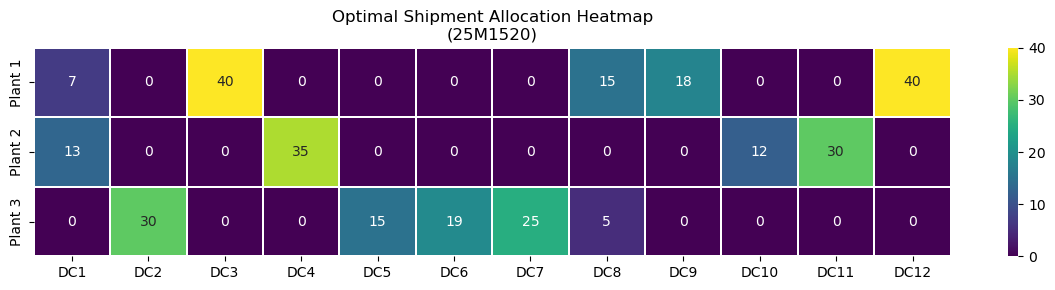

In [8]:
plt.figure(figsize=(12,3))
sns.heatmap(allocation.iloc[:-1,:-1], annot=True, cmap="viridis", linewidths=0.1) # removing total from view
plt.title("Optimal Shipment Allocation Heatmap\n(25M1520)")
plt.tight_layout()
plt.show()

---

# **Exercise 2**

# Question 1

# ***Two-Stage Stochastic LP Formulation :***

### ***Sets :***
$$
i = 1,2,3 \quad \text{(Plants)}
$$
$$
j = 1,\dots,12 \quad \text{(Distribution Centers)}
$$
$$
s \in \mathcal{S} \quad \text{(Scenarios)}
$$

Each center has three possible demand levels:  
Low (L), Medium (M), High (H).

Since demands are independent across 12 centers:

$$
|\mathcal{S}| = 3^{12}
$$

### ***Parameters :***

Medium demand at $DC_j$: $D_j$

Low demand:
$$
D_j^L = 0.7 D_j
$$

High demand:
$$
D_j^H = 1.3 D_j
$$

Probabilities:
$$
P(L)=0.3, \quad P(M)=0.4, \quad P(H)=0.3
$$

Scenario probability:

$$
p_s = \prod_{j=1}^{12} P(\text{level of } j \text{ in scenario } s)
$$

Other parameters:

- Selling price = 20  
- Production cost at plant $i$ = $c_i$  
- Transport cost = $t_{ij}$  
- Scrap value = 5  
- Shortage penalty = 7  

### ***First-Stage Variables (Here-and-Now) :***
Quantity produced at plant $i$:
$$
y_i \ge 0
$$

Capacity constraints:
$$
y_i \le S_i
$$

### ***Second-Stage Variables (Recourse, Scenario-Dependent) :***
Shipment under scenario $s$:
$$
x_{ij}^s \ge 0
$$

Unsold inventory at plant $i$:
$$
u_i^s \ge 0
$$

Shortage at DC $j$:
$$
w_j^s \ge 0
$$

### ***Second-Stage Constraints (for each scenario $s$):***

#### *1. Production balance at plants :*
$$
\sum_{j=1}^{12} x_{ij}^s + u_i^s = y_i
\quad \forall i, s
$$

#### *2. Demand balance at DCs :*
Let demand in scenario $s$ at DC $j$ be $D_j^s$.
$$
\sum_{i=1}^{3} x_{ij}^s + w_j^s = D_j^s
\quad \forall j, s
$$

### ***Objective: Maximize Expected Profit :***

$$
\max \left[ -\sum_{i} c_i y_i + \sum_{s \in S} p_s \left( \sum_{i,j} (20 - t_{ij}) x_{ij}^s + \sum_{i} 5 u_i^s - \sum_{j} 7 w_j^s \right) \right]
$$

subject to

$$
y_i \le S_i
$$

and all recourse constraints above.

### ***Interpretation :***

- First-stage: decide production $y_i$ before demand is known.
- Second-stage: after scenario realization, decide shipment.
- Unsold units earn scrap value 5.
- Shortage incurs penalty 7.
- Objective maximizes expected profit over all scenarios.

---

# Question 2

# ***Number of Scenarios, Variables, and Constraints :***

### ***Number of Scenarios :***

Each of the 12 distribution centers has 3 possible demand states:<br><br>
Low ($0.7 \times \text{demand}$)<br>
Medium ($1.0 \times \text{demand}$)<br>
High ($1.3 \times \text{demand}$)<br>

Therefore,
$$
|S| = 3^{12} = \boxed{531,441} \text{ scenarios}
$$

### ***Number of Variables :***

#### *1. First-stage variables Production decisions :*
$$y_i \quad (i = 1, 2, 3)$$
Total: 
$$ \boxed{3}$$

#### *2. Second-stage variables (per scenario $s$) :*
For each scenario:

Shipments:
$$x_{ij}^s \quad (3 \times 12 = 36)$$

Unsold inventory:
$$u_i^s \quad (3)$$

Shortage:
$$w_j^s \quad (12)$$

Total per scenario:
$$36 + 3 + 12 = \boxed{51}$$

#### *Across all scenarios :*
$$51 \times 3^{12} = 51 \times 531,441 = 27,103,491$$

Total Variables:
$$3 + 27,103,491 = \boxed{27,103,494}$$


### ***Number of Constraints :***

#### *1. First-stage Constraints :*
Capacity constraints:
$$\boxed{3}$$

#### *2. Second-stage Constraints (per scenario $s$):*
For each scenario:
Production balance:3
Demand balance:12

Total per scenario:
$$3 + 12 = \boxed{15}$$

#### *Across all scenarios :*
$$15 \times 3^{12} = 15 \times 531,441 = 7,971,615$$

Total Constraints:
$$3 + 7,971,615 = \boxed{7,971,618}$$

---

# Question 3

# ***Fraction of Scenarios Where Total Demand > Total Capacity***

### ***Step 1: Total Capacity***
$$120 + 90 + 100 = 310$$

### ***Step 2: Demand Statistics***
* Sum of Medium Demands: 304
* Multiplier Distribution:
    - Low (0.7) with probability 0.3
    - Medium (1.0) with probability 0.4
    - High (1.3) with probability 0.3


### ***Step 3: Mean & Variance***
Let, Demand multiplier be $m$
* Expected Multiplier $E[m]$: $0.3(0.7) + 0.4(1.0) + 0.3(1.3) = 1.0$
* Expected Squared-Multiplier $E[m^2]$: $0.3(0.7^2) + 0.4(1.0^2) + 0.3(1.3^2) = 1.054$
* Variance of Multiplier $Var(m)$: $1.054 - 1^2 = 0.054$

* Expected Total Demand $E[T]$: 
$$E[T] = \sum_{j=1}^{12} E[m_j \cdot d_j]$$
$$E[T] = \sum_{j=1}^{12} E[m_j] \cdot d_j$$
$$E[T] =  E[m] \sum_{j=1}^{12}d_j$$
$$E[T] = 1.0 \times 304 = \mathbf{304}$$

* Variance of Total Demand $Var[T]$: 
$$Var[T] = \sum_{j=1}^{12} Var[m_j \cdot d_j]$$
$$Var[T] = \sum_{j=1}^{12} Var[m_j] \cdot d_j^2$$
$$Var[T] =  Var[m] \sum_{j=1}^{12}d_j^2$$
$$Var[T] = 0.054 \times (20^2+30^2+40^2+35^2+15^2+19^2+25^2+20^2+18^2+12^2+30^2+40^2) = \mathbf{470.016}$$

* SD of Total Demand $\sigma[T]$: $\approx 21.68$

### ***Step 4: Right-tail Testing ($H_0$ : Demand = 310, $H_1$ : Demand > 310)***
We use the standard Normal distribution formula to find the Z-score, which represents how many standard deviations the capacity (310) is away from the expected demand (304).

#### *1. Standardization:*
$$Z = \frac{x - \mu}{\sigma}$$

Plugging in the values from our analysis:
* Threshold ($x$): 310 (Total Capacity)
* Mean ($\mu$): 304 (Expected Total Demand)
* Standard Deviation ($\sigma$): $\approx 21.68$
$$Z = \frac{310 - 304}{21.68} = \frac{6}{21.68} \approx \mathbf{0.2768}$$

#### *2. Probability calculation:*
$$P(Z > 0.2768) = \boxed{0.39}$$





# ***Verification with Experiment :***

In [9]:
import itertools
import numpy as np

medium = np.array([20,30,40,35,15,19,25,20,18,12,30,40])
levels = np.array([0.7*medium, medium, 1.3*medium])

capacity = 310
total = 3**12

count_exceed = sum(
    levels[list(s), range(12)].sum() > capacity     # returns bool value
    for s in itertools.product(range(3), repeat=12)
)

print("Total scenarios :", total)
print("Scenarios exceeding capacity :", count_exceed)
print(f"Percentage of scenarios where demand > capacity : {100*(count_exceed / total):.2f}%")

Total scenarios : 531441
Scenarios exceeding capacity : 210724
Percentage of scenarios where demand > capacity : 39.65%


---

# Question 4

*The full deterministic equivalent contains $3^{12} = 531,441$ scenarios, resulting in over **27 million** variables and nearly **8 million** constraints. Such a model is computationally intractable due to memory limitations and solver time complexity. Therefore, we approximate the stochastic problem using a sampled scenario, which significantly reduces problem size and allows practical computation. This approach is consistent with Sample Average Approximation (SAA) methodology.*

In [10]:
np.random.seed(1520)    # for reproducibility

In [11]:
plants = [1, 2, 3]
dcs = list(range(1, 13))

capacity = {1: 120, 2: 90, 3: 100}
medium_demand = {                           # name is changed
    1:20, 2:30, 3:40, 4:35, 5:15, 6:19,
    7:25, 8:20, 9:18, 10:12, 11:30, 12:40
}

prod_cost = {1: 8, 2: 7, 3: 9}
transport_cost = {
    (1,1):2, (1,2):3, (1,3):2, (1,4):3, (1,5):5, (1,6):4.4,
    (1,7):3.2, (1,8):3, (1,9):1.5, (1,10):3, (1,11):6, (1,12):1,
    (2,1):1.9, (2,2):3, (2,3):2.4, (2,4):2.4, (2,5):2, (2,6):4.1,
    (2,7):2.8, (2,8):3, (2,9):1.7, (2,10):2, (2,11):1, (2,12):4.5,
    (3,1):3.1, (3,2):1.8, (3,3):2.8, (3,4):3.4, (3,5):2, (3,6):2.9,
    (3,7):2.2, (3,8):3.2, (3,9):2, (3,10):2.8, (3,11):4.5, (3,12):6
}

selling_price = 20

In [12]:
# generate a random scenario from 3^12 scenarios

dc_state = {}
scenario_demand = {}

for j in dcs:
    r = np.random.choice(["L","M","H"], p=[0.3,0.4,0.3])
    match r:
        case "L":
            scenario_demand[j] = np.ceil(0.7*medium_demand[j])      # ceiling is taken
            dc_state[j] = "Low"
        case "M":
            scenario_demand[j] = medium_demand[j]
            dc_state[j] = "Medium"
        case "H":
            scenario_demand[j] = np.ceil(1.3*medium_demand[j])      # ceiling is taken
            dc_state[j] = "High"

In [13]:
model = pyo.ConcreteModel()
model.I = pyo.Set(initialize=plants)
model.J = pyo.Set(initialize=dcs)

model.y = pyo.Var(model.I, domain=pyo.NonNegativeReals)             # First-stage production
model.x = pyo.Var(model.I, model.J, domain=pyo.NonNegativeReals)    # Shipment
model.u = pyo.Var(model.I, domain=pyo.NonNegativeReals)             # Unsold inventory
model.w = pyo.Var(model.J, domain=pyo.NonNegativeReals)             # Shortage

In [14]:
unsold_scrap = 5
shortage_penalty = 7

def objective_rule(model):
    revenue = sum((selling_price - transport_cost[(i,j)]) * model.x[i,j] for i in model.I for j in model.J)
    production_term = sum(prod_cost[i] * model.y[i] for i in model.I)   # in deterministic case it was included in revenue

    unsold_term = sum(unsold_scrap * model.u[i] for i in model.I)
    shortage_term = sum(shortage_penalty * model.w[j] for j in model.J)
    
    return revenue - production_term + unsold_term - shortage_term

model.obj = pyo.Objective(rule=objective_rule, sense=pyo.maximize)

In [15]:
def capacity_rule(model, i):
    return model.y[i] <= capacity[i]

def production_balance_rule(model, i):
    return sum(model.x[i,j] for j in model.J) + model.u[i] == model.y[i]

def demand_rule(model, j):
    return sum(model.x[i,j] for i in model.I) + model.w[j] == scenario_demand[j]

model.capacity_con = pyo.Constraint(model.I, rule=capacity_rule)
model.production_balance = pyo.Constraint(model.I, rule=production_balance_rule)
model.demand_con = pyo.Constraint(model.J, rule=demand_rule)

In [16]:
solver = pyo.SolverFactory('glpk')
solver.solve(model);

In [17]:
print(f"Optimal Profit = {pyo.value(model.obj):.2f}")

allocation = pd.DataFrame([[pyo.value(model.x[i,j]) for j in dcs] for i in plants],
    index=[f"Plant {i}" for i in plants],
    columns=[f"DC{j}" for j in dcs]
)
allocation["Total Sent"] = allocation.sum(axis=1)
allocation.loc["Total Received"] = allocation.sum(axis=0)

state_row = pd.DataFrame([[dc_state[j] for j in dcs]],
    index=["State"],
    columns=[f"DC{j}" for j in dcs]
)

allocation_table = pd.concat([state_row, allocation])

print("\nOptimal Shipment Allocation Table:")
allocation_table

Optimal Profit = 2981.50

Optimal Shipment Allocation Table:


,DC1,DC2,DC3,DC4,DC5,DC6,DC7,DC8,DC9,DC10,DC11,DC12,Total Sent
State,Low,High,Low,High,High,Medium,Low,Low,High,High,Medium,Low,NaN
Plant 1,14.0,0.0,28.0,12.0,0.0,0.0,0.0,14.0,24.0,0.0,0.0,28.0,120.0
Plant 2,0.0,0.0,0.0,34.0,10.0,0.0,0.0,0.0,0.0,16.0,30.0,0.0,90.0
Plant 3,0.0,39.0,0.0,0.0,10.0,19.0,18.0,0.0,0.0,0.0,0.0,0.0,86.0
Total Received,14.0,39.0,28.0,46.0,20.0,19.0,18.0,14.0,24.0,16.0,30.0,28.0,296.0


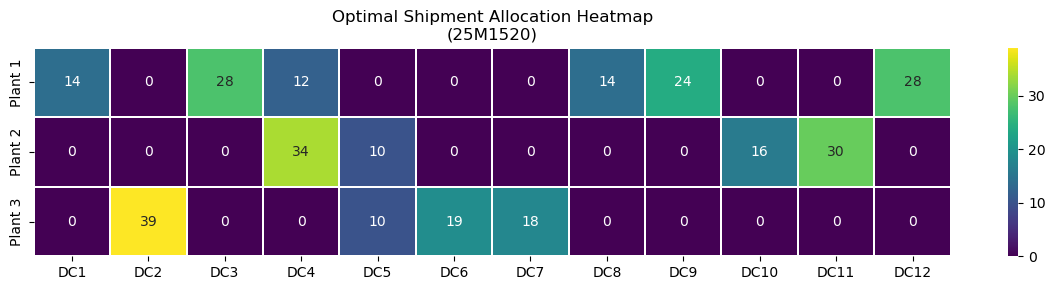

In [18]:
plt.figure(figsize=(12,3))
sns.heatmap(allocation.iloc[:-1,:-1], annot=True, cmap="viridis", linewidths=0.1) # removing total from view
plt.title("Optimal Shipment Allocation Heatmap\n(25M1520)")
plt.tight_layout()
plt.show()

---

# Question 5

# ***Comparison of Deterministic and Stochastic Solutions :***

We compare the production quantities obtained from the deterministic model
(Exercise 1) and the stochastic model (Exercise 2).

### ***Deterministic Model :***

In the deterministic model, demand is assumed to be known and fixed at the
medium demand levels. Therefore, the optimization model produces exactly the
amount required to satisfy this known demand while maximizing profit.

As a result, the production quantities are optimized specifically for the
given demand values without considering any uncertainty.

### ***Stochastic Model :***

In the stochastic model, demand is uncertain and can take three levels:
low, medium, and high. The production decisions must be made before the
actual demand scenario is observed.

Therefore, the model chooses production quantities that maximize the
**expected profit across all possible demand scenarios**.

Because of this uncertainty:

- The model may produce **slightly more** to avoid penalty costs due to lost demand.
- The model may produce **slightly less** to avoid excessive unsold inventory.

Thus, the stochastic model balances the trade-off between:

- lost-demand penalty costs, and
- scrap value of unsold bread.

### ***Comparison :***

The deterministic solution assumes perfect knowledge of demand and therefore
optimizes production for a single demand scenario.

In contrast, the stochastic solution accounts for uncertainty and typically
produces a more **robust production plan** that performs well across many
possible demand realizations.

As a result, the production quantities obtained from the stochastic model may
differ from those of the deterministic model, reflecting the need to hedge
against demand variability.

---